Broj redova i kolona: (2938, 22)

Prvih 5 redova:
        Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   
3  Afghanistan  2012  Developing              59.5            272.0   
4  Afghanistan  2011  Developing              59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   ...  \
0             62     0.01               71.279624         65.0      1154  ...   
1             64     0.01               73.523582         62.0       492  ...   
2             66     0.01               73.219243         64.0       430  ...   
3             69     0.01               78.184215         67.0      2787  ...   
4             71     0.01                7.097109         68.0      3013  ...   

   Polio  Total expenditure  Diphth

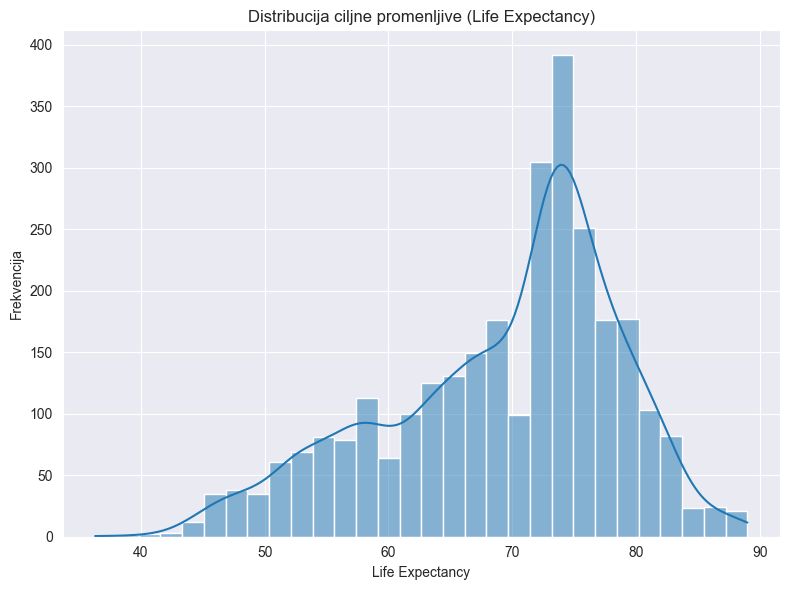

Broj redova nakon uklanjanja NaN u 'Life expectancy': 2928


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

# UČITAVANJE I OSNOVNA ANALIZA PODATAKA


# Učitavanje podataka
df = pd.read_csv("data.csv")

# Pregled osnovnih informacija
print("Broj redova i kolona:", df.shape)
print("\nPrvih 5 redova:\n", df.head())

# Uklanjanje nepotrebnih razmaka u nazivima kolona
df.columns = [c.strip() for c in df.columns]

# Identifikacija ciljne kolone
target_col = "Life expectancy"
print("\nCiljna kolona:", df[target_col].name)

plt.figure(figsize=(8, 6))
sns.histplot(df[target_col].dropna(), bins=30, kde=True)
plt.title("Distribucija ciljne promenljive (Life Expectancy)")
plt.xlabel("Life Expectancy")
plt.ylabel("Frekvencija")
plt.tight_layout()
plt.show()

#Uklanjanje redova gde je ciljna vrednost NaN
df = df.dropna(subset=[target_col])
print(f"Broj redova nakon uklanjanja NaN u '{target_col}': {df.shape[0]}")


In [9]:
# PROVERA I OBRADA NEDOSTAJUĆIH VREDNOSTI


# Pregled broja nedostajućih vrednosti
missing = df.isnull().sum().sort_values(ascending=False)
print("\nNedostajuće vrednosti:\n", missing[missing > 0])



Nedostajuće vrednosti:
 Population                         644
Hepatitis B                        553
GDP                                443
Total expenditure                  226
Alcohol                            193
Income composition of resources    160
Schooling                          160
thinness  1-19 years                32
thinness 5-9 years                  32
BMI                                 32
Diphtheria                          19
Polio                               19
dtype: int64


Numeričke kolone: ['Year', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']
Kategorijske kolone: ['Status']


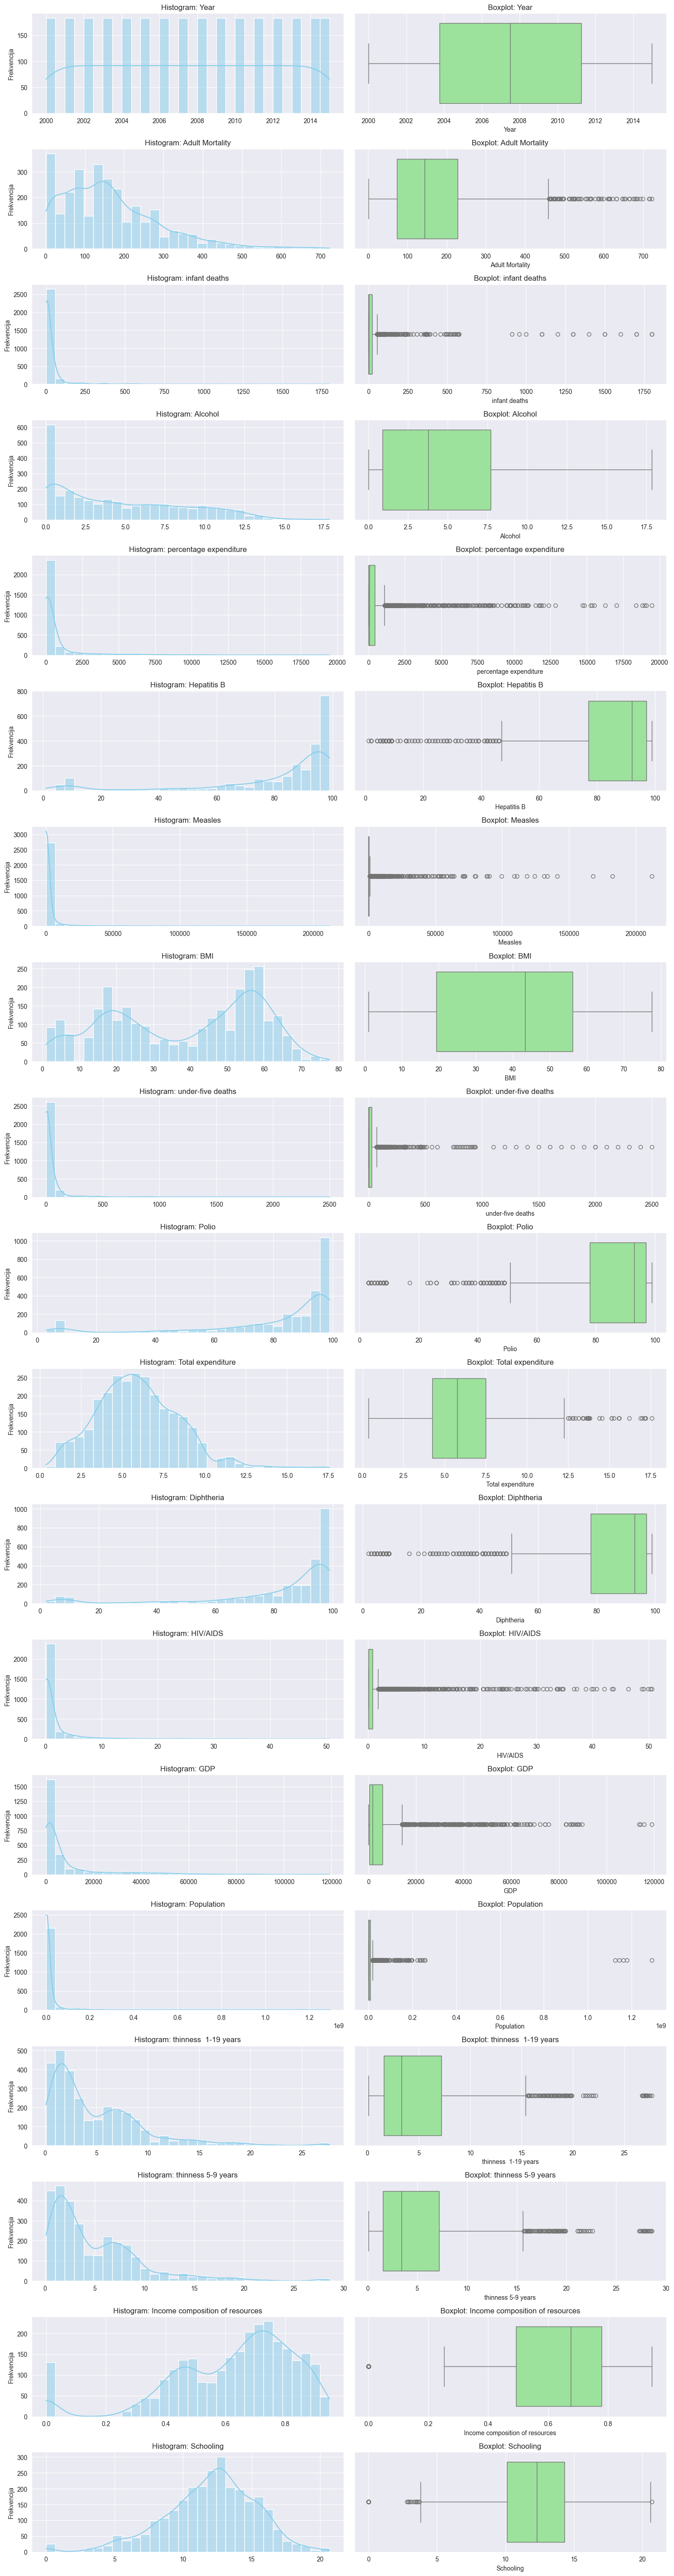

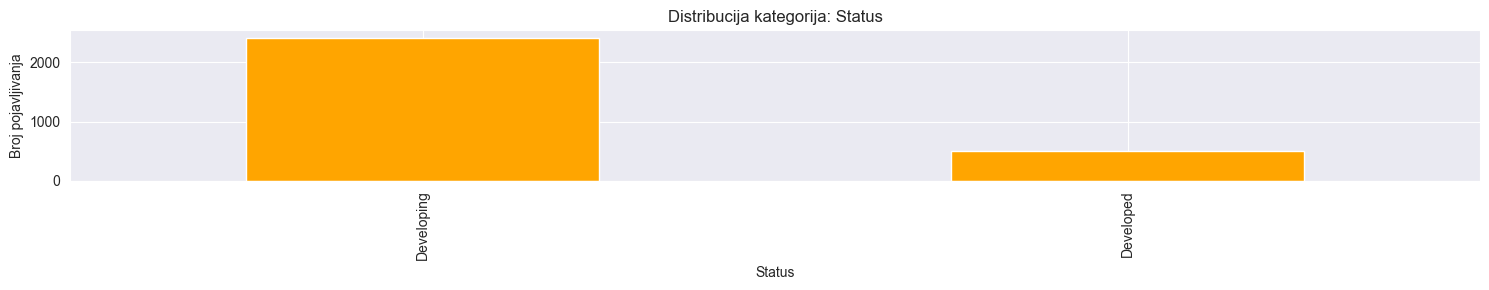

In [10]:
#ODABIR I PRIPREMA ATRIBUTA

# Uklanjanje identifikatora zemlje jer model ne treba da pamti imena država
drop_cols = ['Country']

df = df.drop(columns=drop_cols)
X = df.drop(columns=[target_col])
y = df[target_col]

# Deljenje na trening i test skup (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Identifikacija numeričkih i kategorijskih kolona
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeričke kolone: {num_cols}")
print(f"Kategorijske kolone: {cat_cols}")


#  Histogram + Boxplot za svaku num_cols

plt.figure(figsize=(15, len(num_cols) * 3))
for i, col in enumerate(num_cols, 1):
    # Histogram
    plt.subplot(len(num_cols), 2, 2 * i - 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f"Histogram: {col}")
    plt.xlabel("")
    plt.ylabel("Frekvencija")

    # Boxplot
    plt.subplot(len(num_cols), 2, 2 * i)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()


#   Barplot distribucije za cat_cols

if len(cat_cols) > 0:
    plt.figure(figsize=(15, len(cat_cols) * 3))
    for i, col in enumerate(cat_cols, 1):
        plt.subplot(len(cat_cols), 1, i)
        df[col].value_counts().plot(kind='bar', color='orange')
        plt.title(f"Distribucija kategorija: {col}")
        plt.xlabel(col)
        plt.ylabel("Broj pojavljivanja")

    plt.tight_layout()
    plt.show()
else:
    print("Nema kategorijskih kolona za prikaz.")

In [11]:
# Ciscenje outliera korišćenjem IQR metode pre skaliranja podataka i zato nemamo kruzice
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Zadrži samo vrednosti unutar granica za tu kolonu
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

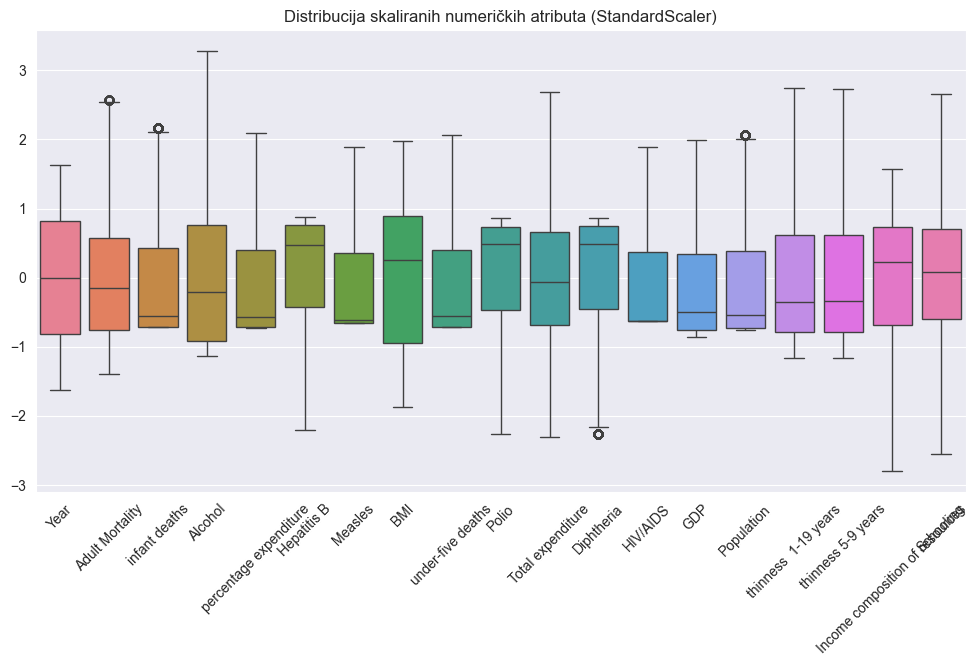

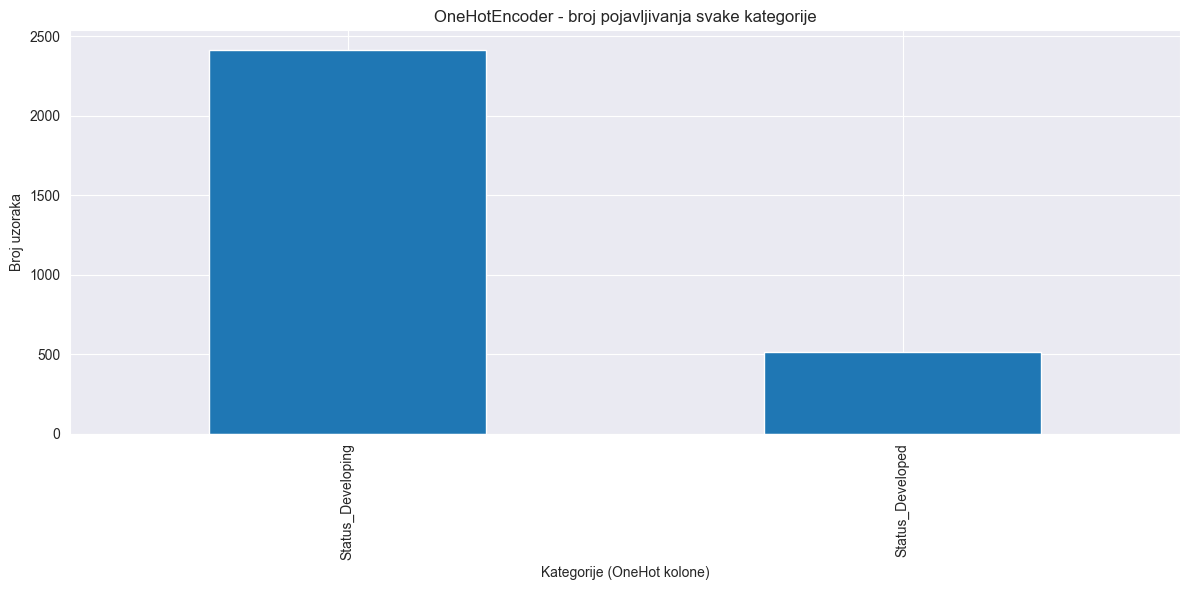

Finalni oblik dataframe-a: (2928, 21)


In [12]:
#PIPELINE ZA PREDOBRADU PODATAKA


num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

# Skaliranje numeričkih kolona
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[num_cols])
scaled_df = pd.DataFrame(scaled_data, columns=num_cols)

# OneHot encoding kategorijskih kolona
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(df[cat_cols])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat_cols))

# Vizualizacija numeričkih podataka
plt.figure(figsize=(12, 6))
sns.boxplot(data=scaled_df)
plt.title("Distribucija skaliranih numeričkih atributa (StandardScaler)")
plt.xticks(rotation=45)
plt.show()

# Vizualizacija kategorijskih (OneHot) kolona
# Prikazujemo samo sumu svake kolone jer ih može biti mnogo
encoded_sums = encoded_df.sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
encoded_sums.plot(kind='bar')
plt.title("OneHotEncoder - broj pojavljivanja svake kategorije")
plt.ylabel("Broj uzoraka")
plt.xlabel("Kategorije (OneHot kolone)")
plt.tight_layout()
plt.show()

# Kombinovani DataFrame
final_df = pd.concat([scaled_df, encoded_df], axis=1)
print("Finalni oblik dataframe-a:", final_df.shape)



In [13]:
# DEFINISANJE MODELA svi regresivni modeli

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42)
}

In [ ]:
# UNAKRSNA VALIDACIJA I PROCENA MODELA
from sklearn.model_selection import cross_validate

# KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # Cross-validation
    scores = cross_validate(
        pipe,
        X, y,
        scoring=['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
        cv=kf
    )

    # Minus jer vece znaci bolje, a nama treba manje da je bolje
    results[name] = {
        'MSE_mean': -scores['test_neg_mean_squared_error'].mean(),
        'MAE_mean': -scores['test_neg_mean_absolute_error'].mean(),
        'R2_mean': scores['test_r2'].mean()
    }

# Ispis rezultata
print("\n--- Rezultati unakrsne validacije ---")
for name, metrics in results.items():
    print(f"{name}: MAE={metrics['MAE_mean']:.2f}, R2={metrics['R2_mean']:.3f}")

In [8]:
# TRENING I TESTIRANJE NA NAJBOLJEM MODELU


# Odabir najboljeg modela prema MAE
best_name = min(results, key=lambda x: results[x]['MAE_mean'])
best_model = models[best_name]

# Trening pipeline-a
final_pipe = Pipeline([('preproc', preprocessor), ('model', best_model)])
final_pipe.fit(X_train, y_train)

# Evaluacija na test skupu
y_pred = final_pipe.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"\nNajbolji model: {best_name}")
print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R2: {r2:.3f}")


Najbolji model: RandomForest
Test MAE: 1.05
Test RMSE: 1.69
Test R2: 0.967



Top 10 najvažnijih atributa:
HIV/AIDS                           0.597038
Income composition of resources    0.170778
Adult Mortality                    0.124287
BMI                                0.019063
under-five deaths                  0.015820
Schooling                          0.010630
thinness 5-9 years                 0.009182
Alcohol                            0.007516
Year                               0.007298
thinness  1-19 years               0.005297
dtype: float64


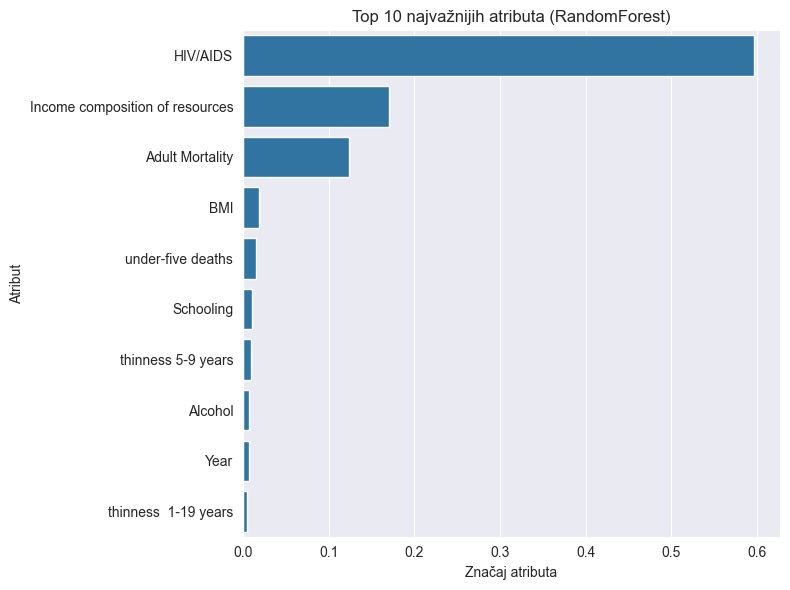

In [9]:
# ANALIZA VAŽNOSTI ATRIBUTA (Feature Importance)


# Random forest and gradient boosting podržavaju feature_importances
if hasattr(best_model, "feature_importances_"):
    # Fit preprocessora da dobijemo finalna imena kolona
    preprocessor.fit(X_train)
    num_feats = num_cols
    cat_feats = []
    if cat_cols:
        cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
        cat_feats = cat_encoder.get_feature_names_out(cat_cols)
    feature_names = np.concatenate([num_feats, cat_feats])
    importances = best_model.feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)

    print("\nTop 10 najvažnijih atributa:")
    print(fi.head(10))

    # Vizualizacija važnosti atributa
    plt.figure(figsize=(8, 6))
    sns.barplot(x=fi.head(10), y=fi.head(10).index)
    plt.title(f"Top 10 najvažnijih atributa ({best_name})")
    plt.xlabel("Značaj atributa")
    plt.ylabel("Atribut")
    plt.tight_layout()
    plt.show()

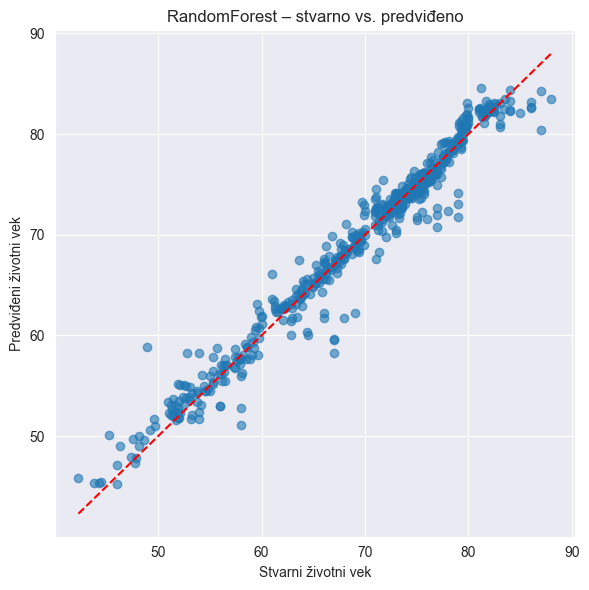

In [10]:
# GRAFIKON: STVARNI VS PREDVIĐENI ŽIVOTNI VEK


plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f"{best_name} – stvarno vs. predviđeno")
plt.xlabel("Stvarni životni vek")
plt.ylabel("Predviđeni životni vek")
plt.grid(True)
plt.tight_layout()
plt.show()